In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN, SAC, TD3
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import EvalCallback


In [2]:
TOTAL_TIMESTEPS = 100_000
LOG_DIR_BASE = "./logs"

def make_env(env_id, log_dir):
    env = gym.make(env_id)
    env = Monitor(env, log_dir)  # needed to log episode rewards to disk
    return env

In [3]:
def train(algo_name, algo_cls, env_id, timesteps=TOTAL_TIMESTEPS):
    log_dir = f"{LOG_DIR_BASE}/{algo_name}_{env_id}"
    import os
    os.makedirs(log_dir, exist_ok=True)

    env = make_env(env_id, log_dir)

    # eval env for periodic evaluation (optional but useful)
    eval_env = make_env(env_id, log_dir + "_eval")
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=log_dir,
        log_path=log_dir,
        eval_freq=2000,
        n_eval_episodes=5,
        deterministic=True,
    )

    model = algo_cls("MlpPolicy", env, verbose=0)
    model.learn(total_timesteps=timesteps, callback=eval_callback)
    model.save(f"{log_dir}/final_model")

    return log_dir


In [4]:
def plot_reward_curve(log_dir, label):
    x, y = ts2xy(load_results(log_dir), "timesteps")
    plt.plot(x, y, label=label)


Training DQN on CartPole-v1 ...
Eval num_timesteps=2000, episode_reward=9.60 +/- 0.49
Episode length: 9.60 +/- 0.49
New best mean reward!
Eval num_timesteps=4000, episode_reward=9.80 +/- 0.75
Episode length: 9.80 +/- 0.75
New best mean reward!
Eval num_timesteps=6000, episode_reward=9.20 +/- 0.75
Episode length: 9.20 +/- 0.75
Eval num_timesteps=8000, episode_reward=9.60 +/- 0.49
Episode length: 9.60 +/- 0.49
Eval num_timesteps=10000, episode_reward=9.40 +/- 0.49
Episode length: 9.40 +/- 0.49
Eval num_timesteps=12000, episode_reward=9.40 +/- 0.80
Episode length: 9.40 +/- 0.80
Eval num_timesteps=14000, episode_reward=9.40 +/- 0.80
Episode length: 9.40 +/- 0.80
Eval num_timesteps=16000, episode_reward=9.80 +/- 0.40
Episode length: 9.80 +/- 0.40
Eval num_timesteps=18000, episode_reward=9.40 +/- 0.80
Episode length: 9.40 +/- 0.80
Eval num_timesteps=20000, episode_reward=9.60 +/- 0.49
Episode length: 9.60 +/- 0.49
Eval num_timesteps=22000, episode_reward=10.40 +/- 0.80
Episode length: 10.40 

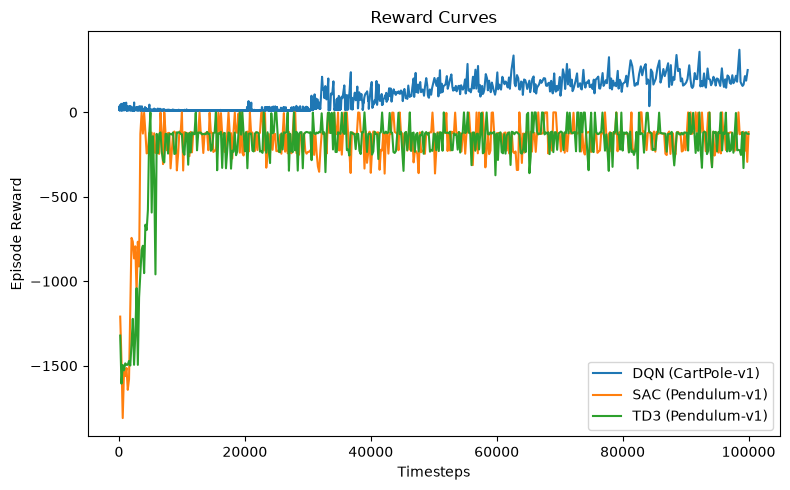

In [5]:

    runs = [
        ("DQN", DQN, "CartPole-v1"),
        ("SAC", SAC, "Pendulum-v1"),
        ("TD3", TD3, "Pendulum-v1"),
    ]
    

    log_dirs = []
    for name, cls, env_id in runs:
        print(f"Training {name} on {env_id} ...")
        log_dir = train(name, cls, env_id)
        log_dirs.append((log_dir, f"{name} ({env_id})"))

    plt.figure(figsize=(8, 5))
    for log_dir, label in log_dirs:
        plot_reward_curve(log_dir, label)
    plt.xlabel("Timesteps")
    plt.ylabel("Episode Reward")
    plt.title("Reward Curves")
    plt.legend()
    plt.tight_layout()
    plt.savefig("reward_curves.png")
    plt.show()

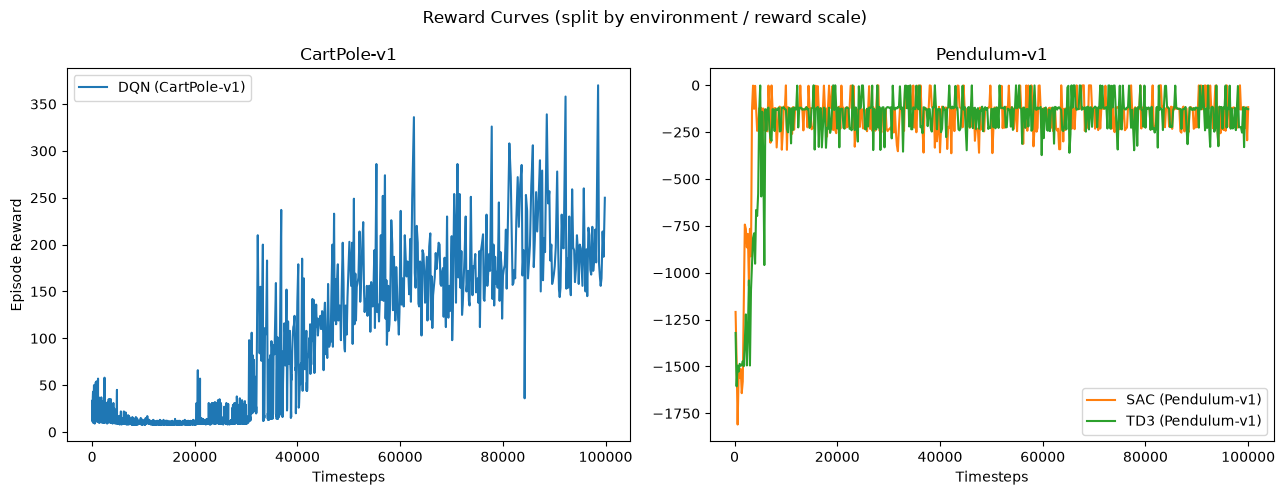

In [6]:
import matplotlib.pyplot as plt
from stable_baselines3.common.results_plotter import load_results, ts2xy
 
LOG_DIR_BASE = "./logs"
 
runs = [
    ("DQN", "CartPole-v1"),
    ("SAC", "Pendulum-v1"),
    ("TD3", "Pendulum-v1"),
]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# --- Subplot 1: DQN / CartPole ---
name, env_id = runs[0]
log_dir = f"{LOG_DIR_BASE}/{name}_{env_id}"
x, y = ts2xy(load_results(log_dir), "timesteps")
axes[0].plot(x, y, label=f"{name} ({env_id})", color="tab:blue")
axes[0].set_title("CartPole-v1")
axes[0].set_xlabel("Timesteps")
axes[0].set_ylabel("Episode Reward")
axes[0].legend()
 
# --- Subplot 2: SAC vs TD3 / Pendulum ---
colors = {"SAC": "tab:orange", "TD3": "tab:green"}
for name, env_id in runs[1:]:
    log_dir = f"{LOG_DIR_BASE}/{name}_{env_id}"
    x, y = ts2xy(load_results(log_dir), "timesteps")
    axes[1].plot(x, y, label=f"{name} ({env_id})", color=colors[name])
axes[1].set_title("Pendulum-v1")
axes[1].set_xlabel("Timesteps")
axes[1].legend()
 
fig.suptitle("Reward Curves (split by environment / reward scale)")
plt.tight_layout()
plt.savefig("reward_curves_split.png", dpi=150)
plt.show()